In [49]:
import os
import json
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.colors as pc
import pandas as pd

In [44]:
def parse_level0(file_path):
    """
    Parse solutions from Level 0 section of EPDE output file.

    Parameters:
    ----------
    file_path : str
        Path to the text file containing symbolic regression results.

    Returns:
    -------
    List[np.ndarray]
        List of solution vectors (each solution is parsed into a numpy array).
    """
    with open(file_path, 'r') as f:
        text = f.read()

    # Level 0
    level0_text = text.split("Level 1:")[0]

    # Solution [...]
    solutions = re.findall(r"Solution \d+:\s*\[([^\]]+)\]", level0_text)

    vectors = []
    for sol in solutions:
        nums = list(map(float, sol.split()))
        vectors.append(np.array(nums))

    return vectors


def get_solution_matrix(folder_path):
    """
    Load and parse solution matrix for a given robot or group.

    Parameters:
    ----------
    folder_path : str
        Path to folder containing EPDE output.

    Returns:
    -------
    np.ndarray
        Matrix of solutions with shape (n_solutions, dimension).
    """
    txt_path = os.path.join(folder_path, "1_parts", "without_force", "obj_func_and_equations.txt")
    solutions = parse_level0(txt_path)
    return np.array(solutions)  # shape: (n_solutions, dim)

def compute_global_mean_and_total_var(level_dict):
    """
    Compute global mean and total variance across groups.

    Parameters:
    ----------
    level_dict : Dict[int, List]
        {
            robot_id: [mean, variance, number_of_samples]
        }

    Returns:
    -------
    Tuple[float, float]
        global_mean : float
            Weighted mean across all robots.
        total_var : float
            Total variance = within-group variance + between-group variance.
    """
    
    robot_ids = list(level_dict.keys())
    group_means = np.array([level_dict[r][0] for r in robot_ids])
    group_vars = np.array([level_dict[r][1] for r in robot_ids])
    group_sizes = np.array([level_dict[r][2] for r in robot_ids])

    # --- Общее среднее ---
    global_mean = np.sum(group_means * group_sizes) / np.sum(group_sizes)

    # --- Внутригрупповая дисперсия ---
    within_var = np.sum(group_vars * group_sizes) / np.sum(group_sizes)

    # --- Межгрупповая дисперсия ---
    between_var = np.sum(group_sizes * (group_means - global_mean)**2) / np.sum(group_sizes)

    # --- Полная дисперсия ---
    total_var = within_var + between_var

    return global_mean, total_var

# Choice type of robots form

In [52]:
robots_form = 'circle' #'oval' or 'circle'
micro_path = Path(robots_form)/"EPDE_output_micro"
mezo_path = Path(robots_form)/"EPDE_output_mezo"

robot_metric = {
    "micro": {},
    "meso_clusters": {},
    "meso_union": {}
}

path_levels_robots_ids = f'{Path(robots_form)}/levels_robots_ids.json'
with open(path_levels_robots_ids, "r") as f:
    levels_robots_ids = json.load(f)


# Circle

In [53]:

clusters = levels_robots_ids['meso_cluster'] 
all_mezo_robots = levels_robots_ids['meso_union'][0]
union_folder = "robot_" + "_".join(map(str, levels_robots_ids['meso_union'][0]))



for folder in os.listdir(micro_path):
    if folder.startswith("robot_"):
        robot = int(folder.split("_")[1])
        path = os.path.join(micro_path, folder)

        mat = get_solution_matrix(path)  
        mat = mat[:, :mat.shape[1] // 2] # (n, 2)
        # среднее по x,y → вектор (n,)
        sol_means = mat.mean(axis=1)

        robot_metric["micro"][robot] = [
            np.mean(sol_means),
            np.var(sol_means),
            len(sol_means)
        ]

for cluster in clusters:
    folder = "robot_" + "_".join(map(str, sorted(cluster)))
    path = os.path.join(mezo_path, folder)

    mat = get_solution_matrix(path) 
    mat = mat[:, :mat.shape[1] // 2]  # (n_solutions, 2 * len(cluster))
    # reshape → (n_solutions, n_robots, 2)
    mat = mat.reshape(mat.shape[0], len(cluster), 2)

    sol_means = mat.mean(axis=2)

    for i, robot in enumerate(cluster):
        robot_metric["meso_clusters"][robot] = [
            np.mean(sol_means[:, i]),
            np.var(sol_means[:, i]), 
            len(sol_means[:, i])
        ]

union_path = os.path.join(mezo_path, union_folder)
mat = get_solution_matrix(union_path)
mat = mat[:, :mat.shape[1] // 2]
n_robots = len(all_mezo_robots)
mat = mat.reshape(mat.shape[0], n_robots, 2)
sol_means = mat.mean(axis=2)

for i, robot in enumerate(all_mezo_robots):
    robot_metric["meso_union"][robot] = [
        np.mean(sol_means[:, i]),
        np.var(sol_means[:, i]),
        len(sol_means[:, i])
    ]
    

micro_mean, micro_total_var = compute_global_mean_and_total_var(robot_metric["micro"])
meso_clusters_mean, meso_clusters_total_var = compute_global_mean_and_total_var(robot_metric["meso_clusters"])
meso_union_mean, meso_union_total_var = compute_global_mean_and_total_var(robot_metric["meso_union"])


print("Micro: mean =", micro_mean, "total_var =", micro_total_var)
print("Meso clusters: mean =", meso_clusters_mean, "total_var =", meso_clusters_total_var)
print("Meso union: mean =", meso_union_mean, "total_var =", meso_union_total_var)

Micro: mean = 0.4481890062167301 total_var = 0.07938270839153638
Meso clusters: mean = 0.8461159694055421 total_var = 0.044813329129605214
Meso union: mean = 1.0235632810666666 total_var = 0.21464877568908697


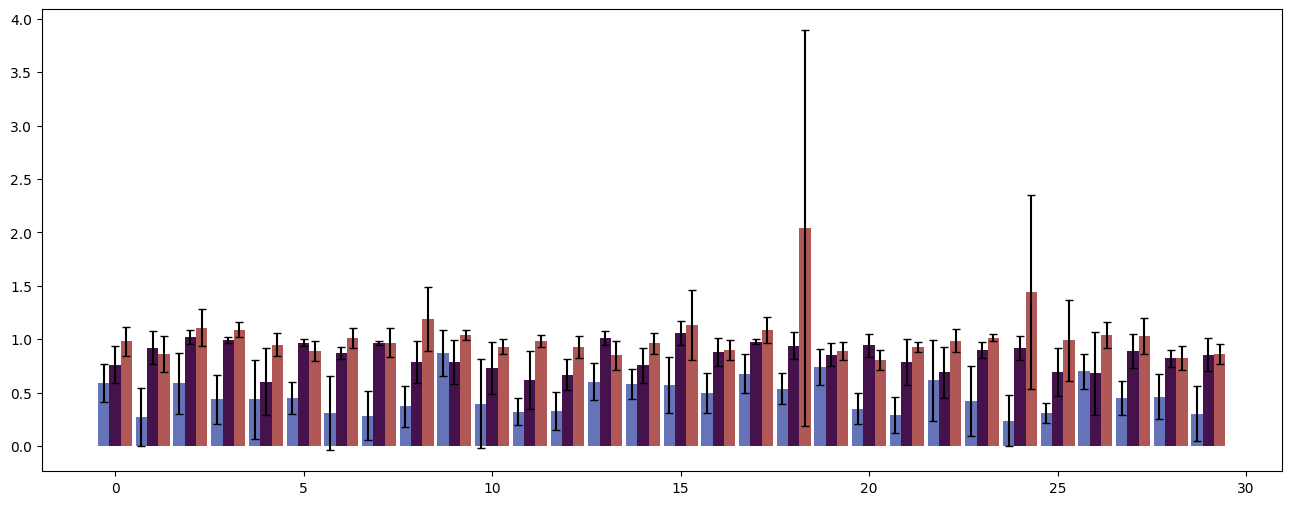

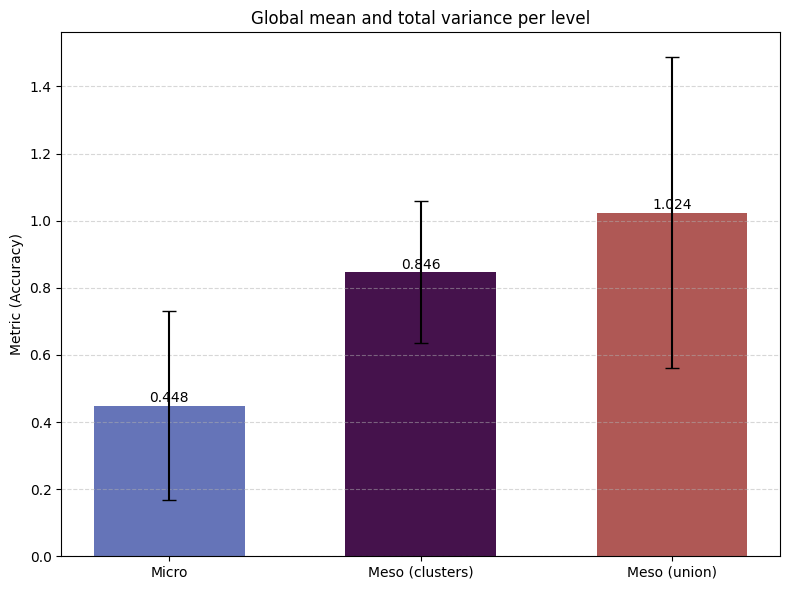

In [54]:
robots = sorted(robot_metric["micro"].keys())
x = np.arange(len(robots))
width = 0.3

micro_means = [robot_metric["micro"][r][0] for r in all_mezo_robots]
micro_vars = [robot_metric["micro"][r][1] for r in all_mezo_robots]

cluster_means = [robot_metric["meso_clusters"][r][0] for r in all_mezo_robots]
cluster_vars = [robot_metric["meso_clusters"][r][1] for r in all_mezo_robots]

union_means = [robot_metric["meso_union"][r][0] for r in all_mezo_robots]
union_vars = [robot_metric["meso_union"][r][1] for r in all_mezo_robots]



# берём цвета
plotly_colors = pc.sample_colorscale(px.colors.cyclical.Twilight, 5)[1:5]

# переводим в matplotlib format
colors = [pc.unlabel_rgb(c) for c in plotly_colors]      # [101,116,184]
colors = [tuple(np.array(c)/255) for c in colors]        # (0.39,0.45,0.72)

plt.figure(figsize=(16, 6))
plt.bar(x - width, micro_means, width,
        yerr=np.sqrt(micro_vars), capsize=3,
        label="Micro", color=colors[0])

plt.bar(x, cluster_means, width,
        yerr=np.sqrt(cluster_vars), capsize=3,
        label="Meso (clusters)", color=colors[1])

plt.bar(x + width, union_means, width,
        yerr=np.sqrt(union_vars), capsize=3,
        label="Meso (union)", color=colors[2])


levels = ["Micro", "Meso (clusters)", "Meso (union)"]
means = [micro_mean, meso_clusters_mean, meso_union_mean]
vars_ = [micro_total_var, meso_clusters_total_var, meso_union_total_var]

x = np.arange(len(levels))
width = 0.6

plt.figure(figsize=(8, 6))

plt.bar(x, means, width,
        yerr=np.sqrt(vars_), capsize=5,
        color=colors[:3])

plt.xticks(x, levels, rotation=0)
plt.ylabel("Metric (Accuracy)")
plt.title("Global mean and total variance per level")

for i, v in enumerate(means):
    plt.text(x[i], v + 0.002, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [37]:

time_data_circle = {
    "Level": ["Micro", "Meso (clusters)", "Meso (union)"],
    "Time (min)": [147, 178, 948]
}

df = pd.DataFrame(time_data_circle)
print(df)

             Level  Time (min)
0            Micro         147
1  Meso (clusters)         178
2     Meso (union)         948


# Oval

In [46]:

clusters = levels_robots_ids['meso_cluster'] 
all_mezo_robots = levels_robots_ids['meso_union'][0]
union_folder = "robot_" + "_".join(map(str, levels_robots_ids['meso_union'][0]))



for folder in os.listdir(micro_path):
    if folder.startswith("robot_"):
        robot = int(folder.split("_")[1])
        path = os.path.join(micro_path, folder)

        mat = get_solution_matrix(path)  
        mat = mat[:, :mat.shape[1] // 2] # (n, 2)
        # среднее по x,y → вектор (n,)
        sol_means = mat.mean(axis=1)

        robot_metric["micro"][robot] = [
            np.mean(sol_means),
            np.var(sol_means),
            len(sol_means)
        ]

for cluster in clusters:
    folder = "robot_" + "_".join(map(str, sorted(cluster)))
    path = os.path.join(mezo_path, folder)

    mat = get_solution_matrix(path) 
    mat = mat[:, :mat.shape[1] // 2]  # (n_solutions, 2 * len(cluster))
    # reshape → (n_solutions, n_robots, 2)
    mat = mat.reshape(mat.shape[0], len(cluster), 2)

    sol_means = mat.mean(axis=2)

    for i, robot in enumerate(cluster):
        robot_metric["meso_clusters"][robot] = [
            np.mean(sol_means[:, i]),
            np.var(sol_means[:, i]), 
            len(sol_means[:, i])
        ]

union_path = os.path.join(mezo_path, union_folder)
mat = get_solution_matrix(union_path)
mat = mat[:, :mat.shape[1] // 2]
n_robots = len(all_mezo_robots)
mat = mat.reshape(mat.shape[0], n_robots, 2)
sol_means = mat.mean(axis=2)

for i, robot in enumerate(all_mezo_robots):
    robot_metric["meso_union"][robot] = [
        np.mean(sol_means[:, i]),
        np.var(sol_means[:, i]),
        len(sol_means[:, i])
    ]
    

micro_mean, micro_total_var = compute_global_mean_and_total_var(robot_metric["micro"])
meso_clusters_mean, meso_clusters_total_var = compute_global_mean_and_total_var(robot_metric["meso_clusters"])
meso_union_mean, meso_union_total_var = compute_global_mean_and_total_var(robot_metric["meso_union"])


print("Micro: mean =", micro_mean, "total_var =", micro_total_var)
print("Meso clusters: mean =", meso_clusters_mean, "total_var =", meso_clusters_total_var)
print("Meso union: mean =", meso_union_mean, "total_var =", meso_union_total_var)

Micro: mean = 0.49956324323582085 total_var = 0.12433908733680511
Meso clusters: mean = 0.9033018369886228 total_var = 0.4388752861722398
Meso union: mean = 1.054160399934643 total_var = 0.14477772284628684


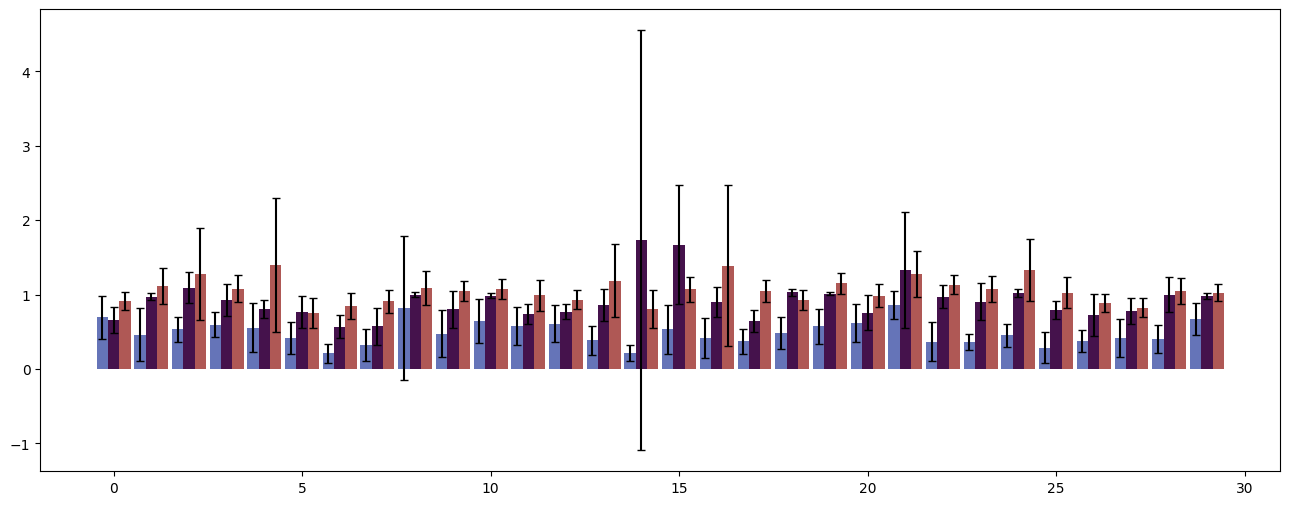

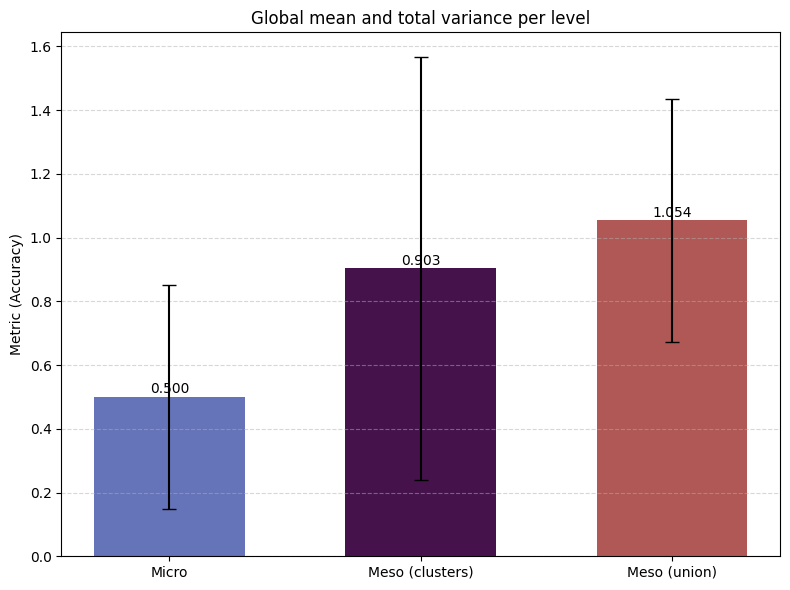

In [51]:
robots = sorted(robot_metric["micro"].keys())
x = np.arange(len(robots))
width = 0.3

micro_means = [robot_metric["micro"][r][0] for r in all_mezo_robots]
micro_vars = [robot_metric["micro"][r][1] for r in all_mezo_robots]

cluster_means = [robot_metric["meso_clusters"][r][0] for r in all_mezo_robots]
cluster_vars = [robot_metric["meso_clusters"][r][1] for r in all_mezo_robots]

union_means = [robot_metric["meso_union"][r][0] for r in all_mezo_robots]
union_vars = [robot_metric["meso_union"][r][1] for r in all_mezo_robots]



# берём цвета
plotly_colors = pc.sample_colorscale(px.colors.cyclical.Twilight, 5)[1:5]

# переводим в matplotlib format
colors = [pc.unlabel_rgb(c) for c in plotly_colors]      # [101,116,184]
colors = [tuple(np.array(c)/255) for c in colors]        # (0.39,0.45,0.72)

plt.figure(figsize=(16, 6))
plt.bar(x - width, micro_means, width,
        yerr=np.sqrt(micro_vars), capsize=3,
        label="Micro", color=colors[0])

plt.bar(x, cluster_means, width,
        yerr=np.sqrt(cluster_vars), capsize=3,
        label="Meso (clusters)", color=colors[1])

plt.bar(x + width, union_means, width,
        yerr=np.sqrt(union_vars), capsize=3,
        label="Meso (union)", color=colors[2])


levels = ["Micro", "Meso (clusters)", "Meso (union)"]
means = [micro_mean, meso_clusters_mean, meso_union_mean]
vars_ = [micro_total_var, meso_clusters_total_var, meso_union_total_var]

x = np.arange(len(levels))
width = 0.6

plt.figure(figsize=(8, 6))

plt.bar(x, means, width,
        yerr=np.sqrt(vars_), capsize=5,
        color=colors[:3])

plt.xticks(x, levels, rotation=0)
plt.ylabel("Metric (Accuracy)")
plt.title("Global mean and total variance per level")

for i, v in enumerate(means):
    plt.text(x[i], v + 0.002, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:

time_data_oval = {
    "Level": ["Micro", "Meso (clusters)", "Meso (union)"],
    "Time (min)": [184, 228, 855]
}

df = pd.DataFrame(time_data_oval)
print(df)

             Level  Time (min)
0            Micro         184
1  Meso (clusters)         212
2     Meso (union)         855
